<a href="https://colab.research.google.com/github/ParnaSaha-Research/Python-workshop-by-Ninbioinformatics/blob/main/Nishad12345(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Department of Microbiology, K K Wagh College of Arts, Science, Commerce and Computer Science, Microbiologists Society, India and NinBioinformatics Services*** Jointly Organised


**One Month Hand's on Workshop on Python for Biologists**

**Mentor's New Notebook**

**Welcome to the Day 15!**

# **File Handling - Reading Basic Text Data**

Today you'll learn how Python interacts with external files, starting with simple text files. This is the foundation for reading sequences, expression tables, and logs.

Theory: (Reading Files)

Opening: The open('filename', 'mode') function opens the file.
We primarily use the 'r' (read) mode today.

The with statement: The best practice for file handling is using with open(...) as file_handle:. This ensures the file is automatically and safely closed, even if errors occur.

Reading Content:

.read(): Reads the entire file content into a single string.

.readline(): Reads only the next single line from the file.

**Pre-Task Setup in Colab:**

Click the folder icon (Files) on the left sidebar.

Click the "New file" icon and name the file geneseq.txt

Double-click the new file and paste the one line of any Sequence in it

***Task 15.1.1***

Create a file 'genseq.txt' and paste an one Sequence in it, open this file and show the entire sequence, as well as show the Data type of Sequence

In [ ]:
with open('genseq.txt', 'r') as seq_file:
  #Syntax for Opening file:
  #with (space) open('file_name.txt', 'r') as one_variable:
  sequence = seq_file.read()
#we have to see the entire content in file, that's why we have used .read()
print("\n******------reading file------******")
print(sequence)
print(type(sequence))


******------reading file------******

<class 'str'>


***Task 15.2.1***

Create new file in drive named as 'geneseq2.txt', Paste one Fasta Sequence in it, read Header and sequence of the same file differently

In [ ]:
print("\n--- Reading Header and Sequence Separately ---")

with open('geneseq2.txt', 'r') as seq_file:
    # Read the first line (header)
    header = seq_file.readline().strip()
    # .strip() means ignore the space, unwanted character
    # Read the second line (sequence)
    data_sequence = seq_file.readline().strip()

print(f"Header: {header}")
print(f"Sequence: {data_sequence}")


--- Reading Header and Sequence Separately ---
Header: >geneseq2 fasta seq | e. coli
Sequence: GCGTAGTCGATCGTAGGTCGATGCGTATTATTAGACG


***Welcome to the day 16***

# **File Handling - Iterating Line-by-Line (FASTA)**

Most biological data files (like FASTA) contain many records. We need to process them efficiently without reading the entire file into memory at once.

Theory:

(Iterating Over File Objects)


A file handle (created using open() or the with statement) is iterable. This means you can use a for loop directly on the file object to process it line-by-line.

**Advantage: This is memory-efficient, as only one line exists in memory at any given time.**

***Task 16.1.1***

Create a one file named as 'multi_fasta.txt' and paste any number of Fasta Sequences in it. Create a record of this Fasta Sequences.

In [ ]:
print("--- Processing Multi-FASTA File ---")
# it is starting of Process, we have to show first sequence as sequence 1, second as sequence 2, hence, we are creating record_count = 0, Later as the processing will go on, this count will be increased by 1
Sequence_count = 0
# with : Safely open and Close the file; ignore any error (if happens)
# open : open the file
# in bracket; first word is file name and extension (type of file) and r means reading mode
# as and fasta_file: we are giving the Temporary name for file
with open('multi_fasta.txt', 'r') as fasta_file:
    # Loop iterates over every line in the file automatically
    for line in fasta_file:
        # Clean up the line by removing leading/trailing whitespace (including newline character)
        cleaned_line = line.strip()

        # Skip empty lines
        if not cleaned_line:
            continue

        # Check if the line is a header line
        if cleaned_line.startswith('>'):
            # This is the header (e.g., >GeneA_101)
            Sequence_count += 1
            seq_metadata = cleaned_line[1:]
            # Slice off the '>' character
            print(f"Sequence Number {Sequence_count}: Sequence Metadata: {seq_metadata}")
        else:
            # This is the sequence data
            print(f"  Sequence: {cleaned_line}")

print("--- Processing Complete ---")

--- Processing Multi-FASTA File ---
Sequence Number 1: Sequence Metadata: NC_003074.8:c3993886-3991117 Arabidopsis thaliana chromosome 3, partial sequence
  Sequence: CGGCTGAGATCTTTACTCGTGAACGTTCTCGAAAGCTCTTTGCCGACCCACTCTTCATTCATATATAAAC
Sequence Number 2: Sequence Metadata: NC_090810.1:10848301-10852754 Solanum lycopersicum chromosome 11, SLM_r2.1
  Sequence: ACAATTTTCCTTCTAATCATTTTCTCATGAAAACCCCATAACCAAGACAGTGACTTTCTCTTTATCTATC
Sequence Number 3: Sequence Metadata: NC_051816.1:1428137-1430527 Canis lupus familiaris isolate SID07034 breed Labrador retriever chromosome 12, ROS_Cfam_1.0, whole genome shotgun sequence
  Sequence: AGCTGCGCAGGCACCGCGGCGTCTCGGCGGCGTCCGCCCCAGCACCTTTCCTTTCGCAGACCCGCTGCGT
Sequence Number 4: Sequence Metadata: NC_010006.1:87443-89275 Bigelowiella natans nucleomorph chromosome 3, complete sequence
  Sequence: ATGTGGATCAAATCCAAAGTTCAAATAATAAGCAATGAAGCGGGTAATCGTACTACAGCTTCTGTTGTAG
Sequence Number 5: Sequence Metadata: NW_020194344.1:c152866-150543 Aspergillus camp

***Welcome to the Day 17***

# **File Handling - Writing Results**

After analysis, you need to save the results. Today, you'll learn how to write output files.

Theory:

Writing Modes and the .write() Method
Modes:

'w' (write): Creates a new file or overwrites an existing file.

'a' (append): Adds content to the end of an existing file.

.write(): Writes the specified string to the file. You must manually add newline characters (\n) if you want content on new lines.

x (Exclusive Creation): The "Safety Lock." It creates a new file but fails (errors out) if the file already exists. This prevents you from accidentally overwriting your precious raw data.

**Task 17.1.1**

Write a new files for storing Sequence and Fasta Sequence using x mode.

In [ ]:
with open("genseq.txt", 'x') as seq_file:

  #with : open and close file safely
  #open : open the file
  #genseq.txt : file name
  #x : mode for file creation
  #as seq file : temporary name for file

  seq_file.write("ATGCGCTAGCGATGTGAC")

w (Write): The "Overwriter." It opens a file for writing. If the file already exists, it deletes everything inside first. If it doesn't exist, it creates a new one.

a (Append): The "Journalist." It opens a file and adds new data to the end of the file. It never deletes what’s already there.

**Task 17.1.2**

Change the sequence in "genseq.txt" using w mode.

In [ ]:
with open("genseq.txt", 'w') as seq_file:
  # w : deletes all the content already existing in file, and written the new content
  seq_file.write(">Fasta seq | Hypothetical fasta seq\n")
  seq_file.write("CAGTGTAGCGATTCGCGTA\n")

**Task 17.1.3**

Append new Fasta Sequence in 'genseq.txt' file using 'a'mode.

In [ ]:
with open("genseq.txt", 'a') as seq_file:
  # a mode is used for appending (addition at the last) new things in already existing content
  seq_file.write(">New Fasta seq | Hypothetical fasta 2\n")
  seq_file.write("ATGCGCTAGCGATGTGAC")

***Note:***

x is a safe mode for creating file

w is a best option for writing a file (but, if content exist in file, w mode will erase that content and will write a new content in the place of deleted one)

a is use for append (addition) in already existing content in file

**Task 17.2.1**

Create one file named as 'calculated_gc_content.csv' and save the results using 'w' mode in Python.

In [ ]:
# Sample data to write
results_data = {
    "GeneA_101": 50.0,
    "GeneB_102": 45.0,
    "GeneC_103": 37.5
}
# this dictionary is the gene name and GC %age data
# Use 'w' mode to create a new file named 'gc_results.csv'

with open('GC_content.csv', 'w') as output_file:
    # 1. Write a header line first (must include '\n')
    header = "Gene_ID,GC_Content_Percent\n"
    output_file.write(header)

    # 2. Iterate through the results data and write each line
    for gene, gc_value in results_data.items():
        # Create a line string and append the newline character
        line = f"{gene},{gc_value:.2f}\n"
        output_file.write(line)

print("Successfully wrote results to GC_content.csv")

Successfully wrote results to GC_content.csv


***Welcome to the Day 18***

# **Introduction to NumPy - High-Performance Arrays**

NumPy (Numerical Python) is the fundamental package for numerical computing in Python. It provides high-performance array objects and tools for working with them.

Theory:

NumPy Arrays

Installation/Import: NumPy is usually pre-installed in Colab. You import it using the standard alias:

import numpy as np.

Arrays vs. Lists: NumPy arrays are faster and more memory-efficient than Python lists for numerical data. Crucially, they perform vectorized operations (applying math to every element simultaneously).

Creation: Use np.array() to create an array from a Python list.

***Task 18.1.1***

You have Provided with ct Values of PCR, Create a numpy array using this data, find the type of array, find the Dimensions and data type of values in an array.

In [ ]:
import numpy as np
"""
import: import this thing/call this thing/start this thing
numpy: name of Library (You have to mention the name of library/ies, as per your need)
as: as
np: nickname for library
"""
# This tells Python to load the NumPy library so you can use its special features
# The "as np" part: This is just a nickname (alias). Instead of typing numpy.something() every time, you can just type np.something(). It saves a lot of typing!
ct_values_list = [22.5, 22.8, 22.4, 23.0, 22.7]
# This creates a standard Python list.
# Context: In lab work, "Ct values" represent how many cycles it took to detect a signal in a PCR machine. Right now, this is just a basic list of numbers, similar to a row in a text file.
ct_array = np.array(ct_values_list)
#This takes your basic list and "upgrades" it into a NumPy Array.
"""
Why do this?
Standard lists are like a bag of items; you can't easily do math on the whole bag at once. NumPy arrays are like a high-performance spreadsheet—they allow you to do complex calculations (like calculating the mean or standard deviation) incredibly fast.
"""
print("--- NumPy Array Creation ---")
print(f"Original List: {ct_values_list}")
print(f"NumPy Array: {ct_array}")
print(f"Type of ct_array: {type(ct_array)}")
# Inspecting the "Metadata"
print(f"Array Shape (dimensions): {ct_array.shape}")
print(f"Data Type of elements: {ct_array.dtype}")
#.shape: This tells you the size of the array. Since you have 5 numbers in a single row, it will say (5,).
#.dtype: This stands for "Data Type." Because your numbers have decimals, NumPy will likely label them as float64 (which is just computer-speak for a decimal number).

--- NumPy Array Creation ---
Original List: [22.5, 22.8, 22.4, 23.0, 22.7]
NumPy Array: [22.5 22.8 22.4 23.  22.7]
Type of ct_array: <class 'numpy.ndarray'>
Array Shape (dimensions): (5,)
Data Type of elements: float64


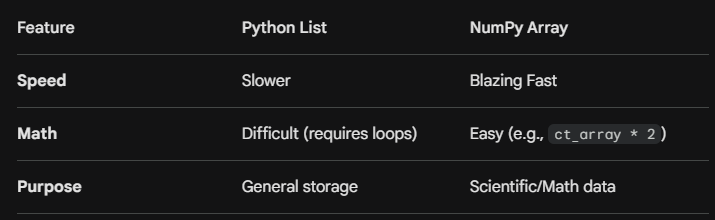

***Task 18.2.1***

Create a Matrix using plate data. find the dimensions of Matrix

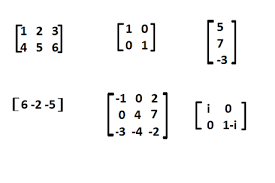

In [ ]:
plate_data = np.array([
    [10.1, 11.5, 9.8], # Row A
    [12.2, 11.9, 10.5]  # Row B
])
"""
The Structure: Notice the nested square brackets [[...], [...]].

The outer brackets [] represent the entire plate.

The inner brackets [...] represent individual rows.

The Translation: In your mind, you can visualize this as a table with 2 rows (Row A and Row B) and 3 columns of data.
"""
print("\n--- 2D Array (Matrix) ---")
print(plate_data)
#When you print a 2D array (Matrix), NumPy formats it so the rows and columns line up visually.

# Checking Dimensions
print(f"Array Shape (rows, columns): {plate_data.shape}")

#.shape: This is the most important attribute for a beginner to check.

#The Result: It will print (2, 3).

#The first number (2) is the number of rows (vertical height).

#The second number (3) is the number of columns (horizontal width).


--- 2D Array (Matrix) ---
[[10.1 11.5  9.8]
 [12.2 11.9 10.5]]
Array Shape (rows, columns): (2, 3)


Why is this useful in the lab?

By organizing your data this way, you can perform math on specific parts of the plate instantly. For example:

plate_data.mean(axis=1): Calculates the average for each row (Row A vs Row B).

plate_data.mean(axis=0): Calculates the average for each column (Well 1, Well 2, and Well 3).

Pro Tip: In NumPy, rows are often referred to as Axis 1 and columns as Axis 0.

***Welcome to the Day 19***

# **NumPy Math - Vectorized Operations**

The real power of NumPy is vectorization: performing math operations on an entire array instantly, without needing a for loop.

Theory: Vectorized Operations
When you apply an arithmetic operator (+, -, *, /) to a NumPy array, the operation is applied element-wise to all components of the array. This is much faster than Python loops.

**Task 19.1.1**

You have provided with the cfu/0.1 ml count from experiment. in a list form, create an array from it.

**Task 19.1.2**

on every plate, 2 colonies were found as a contamination, remove 2 colonies from each value.

**Task 19.1.3**

after removing 2 colonies, consider remaining colonies as corrected counts, Find the total Number of Colonies in a given array.

**Task 19.1.4**

Convert the total counts to cfu/ml

**Task 19.1.5**

Show this value in thousands

**Task 19.1.6**

find the mean, median, mode and standard deviation of data.

In [ ]:
import numpy as np

list_of_cfu = [120, 150, 135, 160, 145] #list of cfu (given data)
print("------- cfu list -----\n")
print(f"cfu list from given data: {list_of_cfu}\n")
# Array Creation using Numpy
"""
syntax for creating array:
name_of_array = np(nickname of numpy).array(list_name)
name of array: give one name for array
np: we are calling library by its nickname
.array : operation to be performed by numpy
list_name: name of list that is to be converted in array
"""
print("\n-------Array from given list-----\n")
cfu_array = np.array(list_of_cfu)
print(f"array created by using given cfu list: {cfu_array}\n")
# Task 19.1.2
"""
Syntax for the Subtraction:
New_name_for_array = name_of_array - number that is to be subtracted
New_name_for_array : give new name to the array

important point:
if you want to add any number in the elements of array:

instead of - use + and number that is to be added
"""
print("\n-----subtracting 2 colonies from each cfu as contaminants-------\n")
corrected_cfu = cfu_array - 2
print(f"corrected colony count: {corrected_cfu}\n")

# sum of entire array:
"""
name_for_sum = np.sum(name_of_corrected_array 'or' name_of_array)
name_for_sum : Assign one name for sum
np : calling numpy by its nickname
.sum : its an operation that performes sum of all the elements in array
name_of_corrected_array or name_of_array : name of array on which operation is to be performed
"""
print("\n----addition of all the elements in array------\n")
total_colonies = np.sum(corrected_cfu)
print(f"total number of colonies: {total_colonies}\n")

# COnverting the count to /ml
# for converting to cfu/0.1ml to cfu/ml it is required to multiply it by 10
"""
Syntax for multiplication:
name_of_operation = name of array 'or' value * number
"""
print("\n----Converting the sum in /ml format-----\n")
cfu_per_ml = total_colonies * 10
print(f"total cfu/ml: {cfu_per_ml}\n")
# creating it in thousands, syntax is same as above, just instead of * we have used /
thousands = cfu_per_ml / 1000
print(f"thousands: {thousands}")
# Finding Mean for corrected cfu array:
"""
name_of_operation = np.mean(name_of_array)
name_of_operation : assign one name for operation
np : calling numpy by its nickname
.mean : its an operation that performes mean of all the elements in array
name_of_array : name of array on which operation is to be performed
"""
print("\n----Finding the mean (average) of corrected array-----\n")
Average_cfu = np.mean(corrected_cfu)
print(f"Average cfu: {Average_cfu}\n")
# finding median for corrected cfu list
# syntax is same as the mean, just in place of .mean we are using .median
print("\n------Finding the median of corrected cfu-------\n")
Median_of_cfu = np.median(corrected_cfu)
print(f"median of corrected cfu: {Median_of_cfu}\n")

# finding standard deviation of corrected cfu list
# Syntax is as same as the .mean,just instead of .mean, we are writing '.std'
print("\n------Finding the Standard Deviation of data from of corrected cfu list------\n")
standard_deviation_cfu = np.std(corrected_cfu)
print(f"sd of cfu: {standard_deviation_cfu:.2f}\n")

------- cfu list -----

cfu list from given data: [120, 150, 135, 160, 145]


-------Array from given list-----

array created by using given cfu list: [120 150 135 160 145]


-----subtracting 2 colonies from each cfu as contaminants-------

corrected colony count: [118 148 133 158 143]


----addition of all the elements in array------

total number of colonies: 700


----Converting the sum in /ml format-----

total cfu/ml: 7000

thousands: 7.0

----Finding the mean (average) of corrected array-----

Average cfu: 140.0


------Finding the median of corrected cfu-------

median of corrected cfu: 143.0


------Finding the Standard Deviation of data from of corrected cfu list------

sd of cfu: 13.64



**Welcome to the Day 20 & 21**

# **Introduction to Pandas - The DataFrame**

Pandas is the essential library for data analysis and manipulation. It's built on NumPy and provides structures for labeled data, most notably the DataFrame.

Theory:

The DataFrame
Installation/Import:

import pandas as pd.

DataFrame: Think of a DataFrame as a spreadsheet stored in memory. It has labeled rows (the Index) and labeled columns.

Series: Each column in a DataFrame is a Pandas Series (a 1D labeled array).

Creation: Commonly created from dictionaries (where keys become column names) or by reading files (like .csv, covered later).

***Task 20.1.1***

Create a small table for Gene Expression data given below

In [ ]:
# Import Pandas with its standard alias 'pd'
import pandas as pd
"""
import: import/install
pandas : name of library
as : as
pd : nickname of library
"""
# Data organized as a dictionary: keys are column names/headers, values are lists of data
#create Dictionary for data
gene_data = {
    'Gene_ID': ['TP53', 'MYC', 'BRCA1', 'GAPDH'],
    'Log2FC': [1.5, 3.2, -0.8, 0.1],  # Log2 Fold Change
    'P_Value': [0.001, 0.00005, 0.15, 0.88], # Statistical significance
    'Type': ['Tumor Suppressor', 'Oncogene', 'Tumor Suppressor', 'Housekeeping']
}

# Create the DataFrame/Table
"""
syntax for creating dataframe:
name_of_dataframe = pd.DataFrame(name_of_dictionary)
"""
df_genes = pd.DataFrame(gene_data)

print("--- Gene Expression DataFrame ---\n")
print(df_genes)

--- Gene Expression DataFrame ---

  Gene_ID  Log2FC  P_Value              Type
0    TP53     1.5  0.00100  Tumor Suppressor
1     MYC     3.2  0.00005          Oncogene
2   BRCA1    -0.8  0.15000  Tumor Suppressor
3   GAPDH     0.1  0.88000      Housekeeping


***Task 20.2.1***

find the information of gene expression dataframe.

In [ ]:
# View information about the DataFrame
# for finding infromation about dataframe we have to use .info()
# Syntax for information:
# dataframe_name.info()
print("\n--- DataFrame Inspection ---\n")
print("Column Names and Data Types (df.info()):\n")
df_genes.info()

# you can get entire statistical Description of dataframe, by using only one formulae
#syntax for description of dataframe:
# print(dataframe_name.describe())
print("\nStatistical Summary of Numerical Columns (df.describe()):")
print(df_genes.describe())

# Syntax for opening csv file using pandas
# pd.read_csv('file_name')


--- DataFrame Inspection ---

Column Names and Data Types (df.info()):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Gene_ID  4 non-null      object 
 1   Log2FC   4 non-null      float64
 2   P_Value  4 non-null      float64
 3   Type     4 non-null      object 
dtypes: float64(2), object(2)
memory usage: 260.0+ bytes

Statistical Summary of Numerical Columns (df.describe()):
        Log2FC   P_Value
count  4.00000  4.000000
mean   1.00000  0.257763
std    1.74547  0.420767
min   -0.80000  0.000050
25%   -0.12500  0.000763
50%    0.80000  0.075500
75%    1.92500  0.332500
max    3.20000  0.880000


# **Mini Project: Finding DEG using pandas and numpy**

You have provided with the data of some genes, based on that find the DEG's responsible for cancer

note:

TS : Tumor suppressor gene

Oncogene : mutated gene of proto-oncogene

HK : House keeping Gene

Log2FC : +1 increased activity; -1 decreased activity; 0 no activity

p value : probablity should be less than 0.05

Additional Mathematical concept:

Mod (Modulus) or Abs (Absoulate)

|+/-x| = x

if

x = 2

|2| = 2

|-2| = 2

In [ ]:
import pandas as pd
import numpy as np # Used for absolute value

# Recreate the DataFrame (for self-contained script)
gene_data = {
    'Gene_ID': ['TP53', 'MYC', 'BRCA1', 'GAPDH', 'PTEN', 'CDK4'],
    'Log2FC': [1.5, 3.2, -0.8, 0.1, -1.2, 2.5],
    'P_Value': [0.001, 0.00005, 0.15, 0.88, 0.03, 0.0001],
    'Type': ['TS', 'Oncogene', 'TS', 'HK', 'TS', 'Oncogene']
}
# creating the dataframe/table using the pandas
df_genes = pd.DataFrame(gene_data)
print("--- Gene Expression DataFrame ---\n")
print(df_genes)
# --- Find Differentially Expressed Genes (DEGs) ---
print("\n")
# 1. Define the two conditions separately
# Condition A: Statistical significance (P_Value < 0.05); p value should be less than 0.05
# syntax of creating condition:
# condition_name = name_of_dataframe['name_of_column'] criteria
significant_condition = df_genes['P_Value'] < 0.05

# Condition B: Fold change magnitude (Log2FC absolute value > 1.0)
#syntax for creating absoulate value using numpy:
# np.abs(value_to_be_converted_in_abs)
# Use np.abs() to get the absolute value
magnitude_condition = np.abs(df_genes['Log2FC']) > 1.0

# 2. Combine the conditions using the AND operator (&)
# Note the parentheses/brackets around each condition!
deg_condition = (significant_condition) & (magnitude_condition)

# 3. Apply the combined Boolean condition to filter the DataFrame
df_degs = df_genes[deg_condition]

print("\n--- Differentially Expressed Genes (DEGs) ---\n")
print(f"Total Genes: {len(df_genes)}\n")
print(f"Number of DEGs Found: {len(df_degs)}\n")
print("\nDEG Table:\n")
print(df_degs)

--- Gene Expression DataFrame ---

  Gene_ID  Log2FC  P_Value      Type
0    TP53     1.5  0.00100        TS
1     MYC     3.2  0.00005  Oncogene
2   BRCA1    -0.8  0.15000        TS
3   GAPDH     0.1  0.88000        HK
4    PTEN    -1.2  0.03000        TS
5    CDK4     2.5  0.00010  Oncogene



--- Differentially Expressed Genes (DEGs) ---

Total Genes: 6

Number of DEGs Found: 4


DEG Table:

  Gene_ID  Log2FC  P_Value      Type
0    TP53     1.5  0.00100        TS
1     MYC     3.2  0.00005  Oncogene
4    PTEN    -1.2  0.03000        TS
5    CDK4     2.5  0.00010  Oncogene


**Welcome to the day 22**

# **Pandas Indexing and Slicing**

how to precisely select and extract data from your Pandas DataFrames using row and column labels (.loc) and integer positions (.iloc)

Theory: Indexing in Pandas
.loc (Label-based Indexing): Uses the actual row and column names (labels) to select data. This is preferred for clarity.

Syntax: df.loc[row_label, column_label]

.iloc (Integer-based Indexing): Uses the numerical position (index) of rows and columns, starting from 0.

Syntax: df.iloc[row_index, column_index]

Slicing: Both .loc and .iloc allow slicing (:) for ranges of rows/columns. Crucially, .loc is inclusive on the end index, while .iloc is exclusive (like standard Python lists).

***Task 22.1.1***

Create a dataframe using data given below, index the data with given ids, access the data for S2A sample and for S1A and S3B show the values only.

In [ ]:
import pandas as pd

# Create a DataFrame where the 'Sample_ID' is set as the index (row labels)
data_dictionary = {
    'Time_Point': ['0h', '0h', '24h', '24h', '48h', '48h'],
    'Value': [10.5, 11.2, 5.8, 6.1, 2.3, 2.8]
}
sample_ids = ['S1A', 'S1B', 'S2A', 'S2B', 'S3A', 'S3B']
df = pd.DataFrame(data_dictionary, index=sample_ids)
# syntax for changing the name of index
# index is row name/number
# name_of_dataframe = pd.DataFrame(name_of_dictionary, index=name_of_list_of_indices)
print("\n--- Initial DataFrame ---\n")
print(df)

# Retrieve all data for a specific sample using its label ('S2A')
# syntax for fetching details for any index:
# name_of_process = df.loc['row_name/index_name']
"""
name_of_process = name of process,
df = name of dataframe
.loc = fetching the name using location (index/row name)
[row_name/index_name] = name of row or index for that data is to be printed/fetched
"""
s2a_data = df.loc['S2A']
print("\n1. Data for Sample S2A (.loc):")
print(s2a_data)

# for example fetching the data for S1B and S2B using .loc:

s1b_s2b_data = df.loc[['S1B','S2B']]
print("\nvalues for S1B and S2B rows\n")
print(s1b_s2b_data)

# Retrieve the 'Value' for two specific samples ('S1A' and 'S3B')
specific_values = df.loc[['S1A', 'S3B'], 'Value']
print("\n2. Value for S1A and S3B (.loc):")
print(specific_values)


# .iloc
print("\n_______.iloc part________\n")

df1 = pd.DataFrame(data_dictionary)
print(df1)


# Retrieve the data for the 3rd and 4th rows (indices 2 and 3)
# [x:y] = printing will be start from x row, but it will stop one step before y






--- Initial DataFrame ---

    Time_Point  Value
S1A         0h   10.5
S1B         0h   11.2
S2A        24h    5.8
S2B        24h    6.1
S3A        48h    2.3
S3B        48h    2.8

1. Data for Sample S2A (.loc):
Time_Point    24h
Value         5.8
Name: S2A, dtype: object

values for S1B and S2B rows

    Time_Point  Value
S1B         0h   11.2
S2B        24h    6.1

2. Value for S1A and S3B (.loc):
S1A    10.5
S3B     2.8
Name: Value, dtype: float64

_______.iloc part________

  Time_Point  Value
0         0h   10.5
1         0h   11.2
2        24h    5.8
3        24h    6.1
4        48h    2.3
5        48h    2.8

3. Data for rows 3 and 4 (.iloc[2:4]):
    Time_Point  Value
S2A        24h    5.8
S2B        24h    6.1

4. 'Value' column using .iloc[:, 1]:
S1A    10.5
S1B    11.2
S2A     5.8
S2B     6.1
S3A     2.3
S3B     2.8
Name: Value, dtype: float64


***Task 22.2.1***

Create a Dataframe using given Dictionary. use '.iloc' to show data for 2nd and 3rd row

***Task 22.2.1***

Show the data in all rows for column of Diameter of Zone of Inhibition.

***Task 22.2.3***

Show the column of strain id and percent reduction using .iloc

In [ ]:
import pandas as pd

mic_mbc_ast_dataset = {
    'row_number' : [1,2,3,4,5],
    'strain_id' : ['A1','A2','A3','A4','A5'],
    'dia_zone_inhi' : [13, 14, 10, 16, 10],
    'mic_tube' : [2, 1, 3, 1, 4],
    'percent_reduction' : [98.60, 99.99, 95.38, 99.99, 94.21]
}

df_mic = pd.DataFrame(mic_mbc_ast_dataset)
print(df_mic)
# task 22.2.1
# separating/acccessing row 2 and 3 data using .iloc
rows_2_and_3 = df_mic.iloc[1:3] # Exclusive end index: includes 2 and 3
print("\nData for rows 2 and 3 (.iloc[1:3]):")
print(rows_2_and_3)

# Retrieve the 'dia_zone_inhi' column (index 3) for all rows
value_column_iloc = df_mic.iloc[:, 3] # ':' means "all rows"
print("\n'dia_zone_inhi' column using .iloc[:, 3]:")
print(value_column_iloc)

# show the data of strain id and percent reduction
strain_id_percent_reduction = df_mic.iloc[:,[1,4]]
print("\nStrain ID and Percent Reduction using:")
print(strain_id_percent_reduction)

   row_number strain_id  dia_zone_inhi  mic_tube  percent_reduction
0           1        A1             13         2              98.60
1           2        A2             14         1              99.99
2           3        A3             10         3              95.38
3           4        A4             16         1              99.99
4           5        A5             10         4              94.21

Data for rows 2 and 3 (.iloc[1:3]):
   row_number strain_id  dia_zone_inhi  mic_tube  percent_reduction
1           2        A2             14         1              99.99
2           3        A3             10         3              95.38

'dia_zone_inhi' column using .iloc[:, 3]:
0    2
1    1
2    3
3    1
4    4
Name: mic_tube, dtype: int64

Strain ID and Percent Reduction using:
  strain_id  percent_reduction
0        A1              98.60
1        A2              99.99
2        A3              95.38
3        A4              99.99
4        A5              94.21


**Welcome to the Day 23**

# **Error Handling (try/except)**

Robust scripts anticipate problems. Error handling allows your code to gracefully manage unexpected inputs or issues without crashing.

Theory: try/except Blocks

try: Python runs the code inside this block. If an error (exception) occurs, it immediately stops executing the try block and jumps to the except block.

except: If an error occurs in the try block, the code in the except block is executed. You can specify the type of error (e.g., ValueError).

**Task 23.1.**

Create Wallace rule formula for finding Melting Temperature of DNA, using try/except rules.

**Explanation and formula for wallace rule**

Short Oligonucleotides (
 bp or basic estimation):
The Wallace rule, or GC/AT method, uses the specific number of bases (often assuming 1M NaCl):

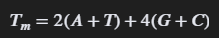

Where
 are the number of respective bases in the primer.



In [ ]:
# DNA Melting Temperature Calculator
print("Melting Temperature Calculator based on wallace rule\n")

print("1. give sequence less than 20 nucleotide; don't add any letter except, A, T, G, C\n")

print("enter the sequence in following dialogue box and press enter:")

sequence = input("Enter a DNA sequence (e.g., ATGC): ").upper()
#This prompts the user for a DNA string and converts it to uppercase so the code isn't confused by "atgc" vs "ATGC"
print(sequence)
print(len(sequence))

try:
    #This starts the block where we "try" to run code that might fail if the user provides bad data.
    if len(sequence) == 0:
      raise ValueError("Sequence cannot be empty!")
    if len(sequence) > 20:
      raise ValueError("Sequence cannot be Greater than 20 nucleotides!")
    # Basic Wallace Rule formula: Tm = 2(A+T) + 4(G+C)
    a_count = sequence.count('A')
    t_count = sequence.count('T')
    g_count = sequence.count('G')
    c_count = sequence.count('C')
    #These lines count the occurrences of each specific nitrogenous base in the string
    # Check if the sequence contains invalid characters
    if len(sequence) != (a_count + t_count + g_count + c_count): #!= means not equal to
        raise ValueError("Sequence contains non-nucleotide characters!")
    # This is a logical check. If the total length of the string is greater than the sum of A, T, G, and C, it means the user typed something else (like "X" or "7").
    # If the check above fails, we manually trigger an error. This "jumps" the code straight to the except block.

    #This is the simplified Wallace Rule formula used for primers shorter than 14-20 base pairs.

    melting_temp = 2 * (a_count + t_count) + 4 * (g_count + c_count)
    print(f"The estimated melting temperature is {melting_temp}°C")

except ValueError as error:
    print(f"Biological Data Error: {error}")
    #This block only runs if a ValueError occurred. It captures the message we wrote ("Sequence contains...") and prints it cleanly.
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    #This is a "safety net" that catches any other weird errors we didn't specifically plan for.

Melting Temperature Calculator based on wallace rule

1. give sequence less than 20 nucleotide; don't add any letter except, A, T, G, C

enter the sequence in following dialogue box and press enter:
Enter a DNA sequence (e.g., ATGC): atgcs
ATGCS
5
Biological Data Error: Sequence contains non-nucleotide characters!


**Welcome to the day 24**

# **Introduction to BioPython - Sequence Objects**

BioPython is the standard toolkit for bioinformatics in Python. Today, you'll start using its core Seq object for sequence manipulation.

Installation: In Colab, you need to install it once per session:

!pip install biopython.

In [ ]:
!pip install biopython

# This cell must be run everytime before using BioPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.7 MB/s eta 0:00:00


Seq Object:

BioPython's representation of a biological sequence (like DNA or RNA). It stores the sequence string but also provides built-in methods optimized for biological calculations.

In bioinformatics, we represent genetic data as strings, but Biopython's Seq object adds biological "intelligence" to those strings (like the ability to easily transcribe or complement them).

**Theory of Transcription and Translation**

Genetic information is written in a chemical alphabet. In Python code, these are represented as strings.

* DNA (Deoxyribonucleic Acid): Uses A, T, C, G. It is the stable, long-term storage of genetic instructions.

* RNA (Ribonucleic Acid): Uses A, U, C, G. It is the "working copy" used to transport instructions.

* Proteins: Made of Amino Acids (represented by single-letter codes like M, F, S, Y). These are the "machines" that do the work in the cell.

Directionality and the "Double Helix"

DNA is double-stranded, and the two strands run in opposite directions (antiparallel).

5' (Five-prime) and 3' (Three-prime): These numbers refer to the carbon atoms in the sugar backbone. By convention, scientists always read and write sequences from 5' to 3'.

The Coding Strand (5' to 3'): This strand looks almost identical to the eventual mRNA.

The Template Strand (3' to 5'): This is the "mirror image" that the cell actually reads to build the RNA.

Base Pairing Rules (Complementarity)


In DNA, chemicals always pair up in specific "handshakes":

A pairs with T (or U in RNA)

C pairs with G

***The Three Stages of Genetic Flow***

**Phase A: Complementarity and Reversal**

Because DNA is double-stranded, if you have the sequence for one side (the Template), you can mathematically determine the other side (the Coding strand).

* Complement: Swapping the letters (A $\leftrightarrow$ T).

* Reverse Complement: Swapping the letters AND flipping the string so it reads in the standard 5' to 3' direction.

**Phase B: Transcription (DNA $\rightarrow$ mRNA)**

This is the process of copying DNA into RNA.

* The Action: The cell replaces Thymine (T) with Uracil (U).

* The Result: A messenger RNA (mRNA) molecule that can leave the nucleus to go to the "factory" (the ribosome).

**Phase C: Translation (mRNA $\rightarrow$ Protein)**

This is where the "language" changes from nucleotides to amino acids.

* Codons: The ribosome reads the mRNA in "words" of 3 letters. Each 3-letter word (like AUG) translates to one Amino Acid (like Methionine).

* The Genetic Code Table: There is a universal "dictionary" used to look up these codons. However, some organisms (like Yeast mitochondria) use a slightly modified dictionary, which is why Biopython allows you to specify different tables.

* The Stop Codon: Certain 3-letter words tell the ribosome to "Stop," marked in code as an asterisk (*).

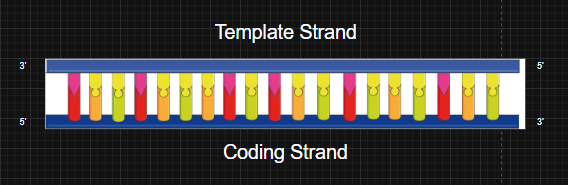

***Task 24.1.1***

Create a Complement strand, Reverse Complement, mRNA and Amino acid Sequence for any Gene sequence in NCBI

In [ ]:
# --- STEP 1: Setup ---
# Import the Seq object from Biopython's Bio.Seq module
from Bio.Seq import Seq
# Bio means BioPython
# .Seq means Sequence library used for Sequence related work
# --- STEP 2: Input Sequence ---
# This is a sample sequence (often found on NCBI).
# We treat this as the Coding Strand (5' to 3')
dna_input = input("Input DNA Strand:")
coding_dna = Seq(dna_input).replace("\n", "").replace("\r", "").replace(" ","")
# seq before the (dna_input) will create the inserted DNA sequence as the Sequence for Biopython
print("--- 1. INITIAL DNA ANALYSIS ---")
print(f"Original Coding DNA (5' to 3'): {coding_dna}")
print(f"Length of Sequence: {len(coding_dna)} bp")

# --- STEP 3: DNA Relationships ---
# Generate the mirror-image strands
# .complement() swaps A<->T and C<->G
# .reverse_complement() swaps bases AND flips the direction (3' to 5' becomes 5' to 3')
print("\n--- 2. COMPLEMENTARY STRANDS ---\n")
# syntax for creating Complementary Strand of DNA
# name_of_complementary_strand = name_of_dna.complement()

complement_dna = coding_dna.complement()
print(f"Complementary DNA: {complement_dna}")

# syntax for creatin Reverse Complementary Strand of DNA
# name_of_rev_comp_strand = name_of_dna.reverse_complement()

rev_comp_dna = coding_dna.reverse_complement()
print(f"Reverse Complement Strand: {rev_comp_dna}")

# --- STEP 4: Transcription (DNA to mRNA) ---
# The .transcribe() method converts DNA Thymine (T) to RNA Uracil (U)
# This results in a Messenger RNA (mRNA) molecule
# Syntax for Transcription
# name_for_mRNA = name_of_dna.transcribe()
mrna = coding_dna.transcribe()

print("\n--- 3. TRANSCRIPTION ---")
print(f"mRNA Sequence: {mrna}")

# --- STEP 5: Translation (mRNA to Protein) ---
# The .translate() method reads mRNA in groups of 3 (codons)
# It maps them to Amino Acids using the Standard Genetic Code (Table 1)
# Syntax for Translation
# name_for_protein = name_of_mRNA.translate()
protein = mrna.translate()

# We can also use specific tables

print("\n--- 4. TRANSLATION (AMINO ACIDS) ---")
print(f"Protein: {protein}")
print(f"length of protein sequence: {len(protein)}")
print("-" * 300)

Input DNA Strand:ATCTTATTTTTATTTGTTTACATGTCTTTTCTTATTTTAGTGTCCTTAAAAGGTTGATAATCACTTGCTR AGTGTGTTTCTCAAACAATTTAATTTCAGGAGCCTACAAGAAAGTACGAGATTTAGTCAACTTGTTGAAG AGCTATTGAAAATCATTTGTGCTTTTCAGCTTGACACAGGTTTGGAGTGTAAGTGTTGAATATCCCAAGA ATGACACTCAAGTGCTGTCCATGAAAACTCAGGAAGTTTGCACAATTACTTTCTATGACGTGGTGATAAG ACCTTTTAGTCTAGGTTAATTTTAGTTCTGTATCTGTAATCTATTTTTAAAAAATTACTCCCACTGGTCT CACACCTCA
--- 1. INITIAL DNA ANALYSIS ---
Original Coding DNA (5' to 3'): ATCTTATTTTTATTTGTTTACATGTCTTTTCTTATTTTAGTGTCCTTAAAAGGTTGATAATCACTTGCTRAGTGTGTTTCTCAAACAATTTAATTTCAGGAGCCTACAAGAAAGTACGAGATTTAGTCAACTTGTTGAAGAGCTATTGAAAATCATTTGTGCTTTTCAGCTTGACACAGGTTTGGAGTGTAAGTGTTGAATATCCCAAGAATGACACTCAAGTGCTGTCCATGAAAACTCAGGAAGTTTGCACAATTACTTTCTATGACGTGGTGATAAGACCTTTTAGTCTAGGTTAATTTTAGTTCTGTATCTGTAATCTATTTTTAAAAAATTACTCCCACTGGTCTCACACCTCA
Length of Sequence: 359 bp

--- 2. COMPLEMENTARY STRANDS ---

Complementary DNA: TAGAATAAAAATAAACAAATGTACAGAAAAGAATAAAATCACAGGAATTTTCCAACTATTAGTGAACGAYTCACACAAAGAGTTTGTTAAATTAAAGTCCTCGGATGTTCTTT

/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [ ]:
# sequence
# ATGCATGCATGCATGC

# complement
# TACGTACGTACGTACG

#Reverse complement
# GCATGCATGCATGCAT

**Welcome to the day 25**

# **BioPython: Alignments (Pairwise)**
Sequence alignment is critical for finding homology. BioPython provides tools to perform simple local and global alignments.

Theory:

Alignment
Global Alignment (Needleman-Wunsch):

Tries to align every residue in two sequences across their entire length.

Local Alignment (Smith-Waterman):

Finds the highest scoring regions of similarity between two sequences.

BioPython: Uses the Bio.Align.PairwiseAligner class. You must set parameters like match/mismatch scores and gap penalties.

***Task 25.1.1***

Align the any two sequences, find the Alignment Score for the same.

match_score = 2 (The Reward)
This is the prize for finding identical characters in the same position (e.g., A matching with A).

Meaning: Every time the sequences align perfectly at a position, the total score increases by 2.

Why 2? It’s a positive weight that encourages the algorithm to find as many matches as possible.

---

mismatch_score = -1 (The Penalty)
This is the "fine" for lining up two different characters (e.g., A matching with C).

Meaning: If the aligner forces a mismatch to keep the rest of the sequence aligned, it "pays" 1 point.

Biology: In nature, a mismatch represents a point mutation. Since mutations are relatively rare, we penalize them.

---

open_gap_score = -0.5 (The Cost of Starting)
A "gap" (represented by a -) occurs when one sequence has an insertion or deletion that the other does not.

Meaning: The moment the aligner decides it needs to skip a character and start a gap, it loses 0.5 points.

Biology: It takes a significant "evolutionary effort" to add or delete a base.

---

extend_gap_score = -0.1 (The Cost of Staying)
This is the penalty for making an existing gap longer.

Meaning: If a gap is already open, adding more dashes to it only costs 0.1 points per dash.

Why is it smaller than the open score? This is called Affine Gap Penalty. Biologically, a single mutation event often deletes a chunk of DNA (5–10 bases) at once. It is more likely that one big gap occurred than five tiny, separate gaps. By making the "extend" penalty cheaper, you encourage the aligner to group gaps together rather than scattering them.

In [ ]:
# importing required libraries for work
from Bio.Align import PairwiseAligner
from Bio.Seq import Seq
# creating Dialogue box for entering the Sequence
# .replace("\n", "").replace("\r", "").replace(" ","") this code is for removing enter, spaces, etc. from sequence
seq1 = Seq(input("Enter 1st Sequence")).replace("\n", "").replace("\r", "").replace(" ","")
seq2 = Seq(input("Enter 2nd Sequence")).replace("\n", "").replace("\r", "").replace(" ","")
"""
input(...): Prompt the user to paste a sequence.

.replace("\n", "").replace("\r", "").replace(" ",""): This is your "cleanup crew." It removes line breaks (common in NCBI fasta files) and accidental spaces so the sequence is one continuous string.

Seq(...): Converts that cleaned string into a Biopython Seq object.
"""
# --- 1. Initialize the Aligners ---
aligner = PairwiseAligner()
"""
This creates the "engine" that will perform the math. PairwiseAligner is the modern, faster replacement for the older Bio.pairwise2 module.
"""
# Set local alignment mode (Smith-Waterman)
aligner.mode = 'local'
"""
Local Alignment (Smith-Waterman): Finds the best-matching "island" within the sequences. It’s great for finding conserved domains even if the rest of the sequences are totally different.

Global mode (default) would try to align them from end-to-end.
"""
# Set scores (match is +2, mismatch is -1)
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -0.5
aligner.extend_gap_score = -0.1
"""
These values determine the "logic" of the alignment. By making extend_gap_score lower than open_gap_score (Affine Gap Penalty), you tell the AI that it's "cheaper" to keep a gap going than to start a new one—this mimics biological evolution more accurately.
"""
print("--- Simple Local Alignment ---")
print(f"Seq 1: {seq1}")
print(f"Seq 2: {seq2}")
"""
This doesn't just return one result; it returns an Alignment object (an iterator) containing all possible alignments that achieved the highest score.
"""
# --- 2. Perform and Score the Alignment ---
# aligner.align(seq1, seq2)
# this will align seq 1 and seq 2 and will calculate the score using values we have decided
alignments = aligner.align(seq1, seq2)
"""
alignments.score: This calculates the maximum score possible based on your rules above.

:.2f: A formatting trick to show only two decimal places (e.g., 15.50).
"""
# The score is the highest possible score found
# this will count the score of alignment
best_score = alignments.score
print(f"\nBest Alignment Score: {best_score:.2f}")

# --- 3. Print the Best Alignment ---
# Print the first (best) alignment found
"""
alignments[0]: Since there might be many alignments with the same high score, this selects the first one in the list.

print(...): Biopython's Alignment objects have a built-in "pretty print" feature. It will show you the two sequences stacked, with | or . symbols to show matches and gaps visually.
"""
print("\nBest Alignment:")
print(alignments[0])


Enter 1st SequenceATGATTAGAGCCTACGAACAAAACCCACAACATTTTATTGAGGATCTAGAAAAAGTTAGGGTGGAACAAC TTACTGGTCATGGTTCTTCAGTTTTAGAAGAATTGGTTCAGTTAGTCAAAGATAAAAAGATAGATATTTC CATTAAATATGATCCCAAAAAAGATTCGGAAGTTTTTGCCAATAGGGTAATTACTGATGATATCGAATTA CTCAAGAAAATCCTGGCTTATTTTCTACCCGAGGATGCCATTCTTAAAGGCGGTCATTATGACAACCAAC TGCAAAATGGCATCAAGCGAGTAAAAGAGTTCCTTGAATCATCGCCGAATACACAATGGGAGTTGCGGGC GTTCATGGCAGTAATGCATTTCTCTTTAACCGCCGATCGTATCGATGATGATATTTTGAAAGTGATTGTT GATTCAATGAATCATCATGGTGATGCCCGTAGCAAGTTGCGTGAAGAATTAGCTGAGCTTACCGCCGAAT TAAAAATTTATTCAGTTATTCAAGCTGAAATTAATAAGCATCTGTCGAATAGTGACACCATAAATATCCA TGATAAATCAATTAATCTCATGGATAAAAATTTATATGGTTATACAAATGAAGAGATTTTTAAAGCCAGC GCAGAGTACAAAATTCTCGAGAAAATGTCTCAAACCACCATTAAGGAAGGTGAGACCGAAAAAAAAATAG TCTCGATAAAGAACTTTCTTGAAAGTGAGAATAAAAGAACCGGGGCGTTGGGTAACCTGAAAGATTCATA CTCTTATAATAAAGATAATAATGAATTATCTCACTTTGCCACCACCTGCTCGGATAAGTCCAGGCCGCTC AACGACTTGGTTAGCCAAAAAACAACTCAGCTGTCTGATATTACATCACGTTTTAATTCAGCTATTGAAG CACTGAACCGTTTCATTCAGAAATATGATTCAGTGATGCAACGTCTGCTAGATGACACG

**Welcome to the day 26 & 27**

# **Introduction to Plotting (Matplotlib)**

Visualization is vital for biological data interpretation. Matplotlib is the foundational plotting library in Python.

Theory:

Matplotlib

Import:You usually import the pyplot module with the alias plt:

import matplotlib.pyplot as plt

Creating a Plot: The general workflow is:

define data $\to$ call a plot function (e.g., plt.scatter()) $\to$ add labels (plt.xlabel(), plt.ylabel()) $\to$ display (plt.show()).

Colab Note: In Colab, plots are usually displayed automatically without plt.show() when the cell finishes, but it's good practice to include it.
____

**1.Line Plot (The Growth Curve)**

This is the most fundamental plot. Use it to show how a variable changes over a continuous interval (usually time).

Biological Case: Bacterial population growth over 24 hours or a temperature gradient for enzyme activity.

Key Function: plt.plot(x, y)

**The Line Plot: Bacterial Growth Curve**

This demonstrates how a population changes over time. We will use a logarithmic-style growth curve.

/tmp/ipykernel_725/3278232978.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # Shows the label defined in plt.plot


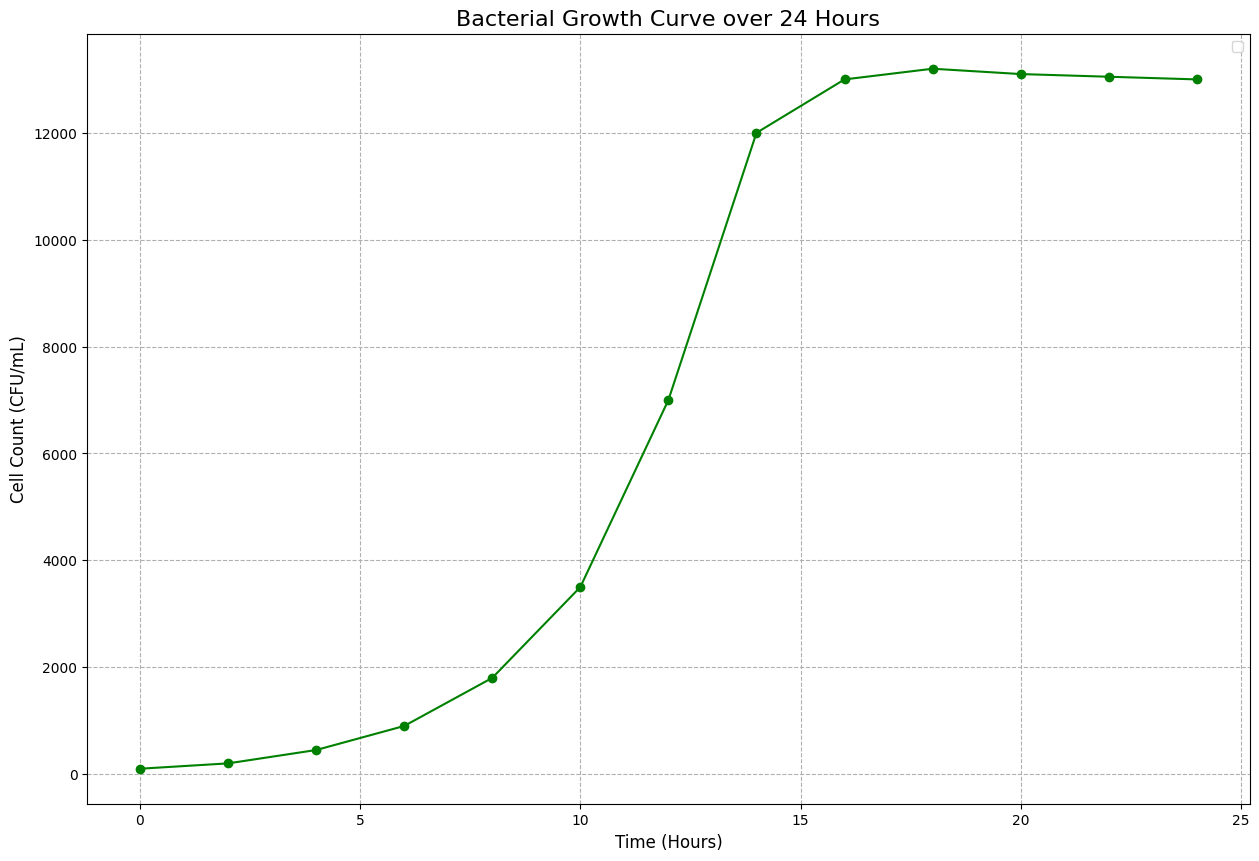

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
"""
in case of emergency
plt.rcdefaults()
"""
# 1. Create a Synthetic Dataset
# Time in hours (0 to 24)
time = np.arange(0, 25, 2)
"""
.arange(start, stop, step)
array+range
"""

# Bacterial count (CFU/mL) - simulating exponential then stationary phase
cells = [100, 200, 450, 900, 1800, 3500, 7000, 12000, 13000, 13200, 13100, 13050, 13000]

# 2. Initialize the plot
plt.figure(figsize=(15, 10))

# 3. Plot the data
# means Green color (of line), Circle markers, and Solid line
plt.plot(time, cells, color='green', marker='o', linestyle='-')

# 4. Annotations (Crucial for Science)
plt.title('Bacterial Growth Curve over 24 Hours', fontsize=16)
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Cell Count (CFU/mL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=1) # Adds a subtle grid for readability
plt.legend() # Shows the label defined in plt.plot

# 5. Display
plt.show()

___
**2.Bar Chart (Categorical Comparison)**

Perfect for comparing discrete groups.

Biological Case: Comparing the number of species found in different habitats (Forest vs. Grassland) or the average height of plants treated with different fertilizers.

Key Function: plt.bar(categories, values)

**The Bar Chart: Comparing Protein Concentrations**

This is ideal for comparing different samples or treatment groups.

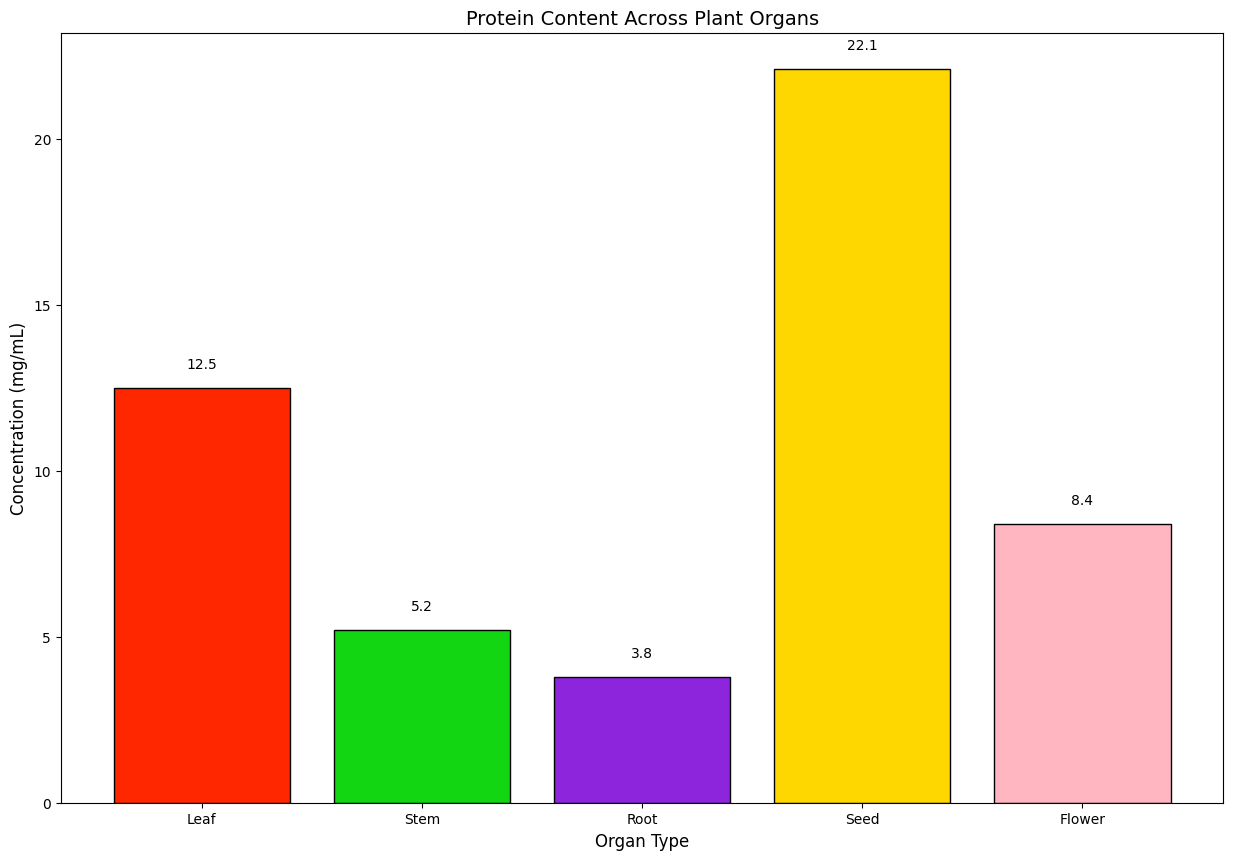

In [ ]:
import matplotlib.pyplot as plt

# 1. Dataset: Protein concentration (mg/mL) in different plant extracts
samples = ['Leaf', 'Stem', 'Root', 'Seed', 'Flower']
concentration = [12.5, 5.2, 3.8, 22.1, 8.4]

# 2. Create the Bar Chart
plt.figure(figsize=(15, 10))
colors = ['#FF2700', '#13D613', '#8C25DB', 'gold', 'lightpink'] # Custom colors for groups
# color codes can be find from 'html color code' website
bars = plt.bar(samples, concentration, color=colors, edgecolor = 'black')

# 3. Adding Value Labels on top of bars
for bar in bars:
    # When we created the plot using bars = plt.bar(...), Matplotlib created a list of "Rectangle" objects (one for each organ: Leaf, Stem, etc.).
    #This loop looks at every single bar on your graph, one at a time.
    yval = bar.get_height()
    # Each bar has a height that represents the biological data (e.g., 12.5 mg/mL for the Leaf).
    # We ask the bar, "How tall are you?" and store that number in a variable called yval. We will use this number twice: once to know where to put the text, and once for what the text should say.
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')
    # The plt.text function needs three main things to work: a horizontal position (x), a vertical position (y), and the string to display.
    # The X-Position (bar.get_x() + bar.get_width()/2):
    # bar.get_x() gives us the left edge of the bar.
    # Adding bar.get_width()/2 moves the "cursor" to the exact middle of the bar. Without this, the text would start at the left edge and look messy.

# 4. Annotations
plt.title('Protein Content Across Plant Organs', fontsize=14)
plt.ylabel('Concentration (mg/mL)', fontsize=12)
plt.xlabel('Organ Type', fontsize=12)

plt.show()

___
**3.Scatter Plot (Correlation & Trends)**

Use this to see if two numerical variables are related.

Biological Case: Correlating Leaf Length vs. Leaf Width, or Body Mass vs. Metabolic Rate in different mammals.

Key Function: plt.scatter(x, y)

**The Scatter Plot: Enzyme Kinetics (V vs [S])**

Use this to show the relationship between substrate concentration and reaction velocity.

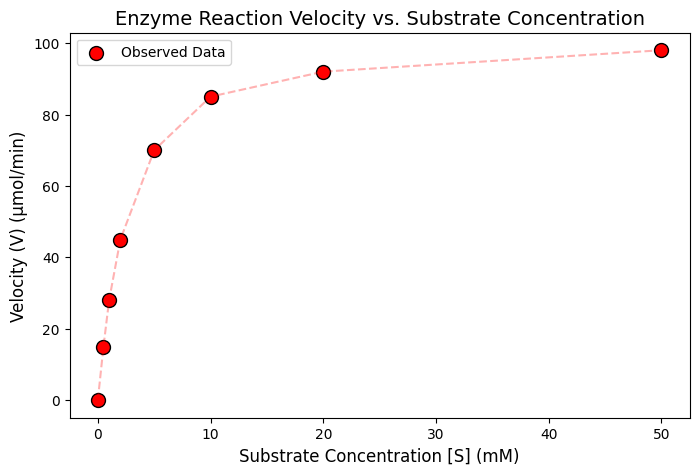

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create Dataset
# Substrate concentration [S]
substrate = np.array([0, 0.5, 1, 2, 5, 10, 20, 50])
# Reaction velocity (V) mimicking Michaelis-Menten kinetics
velocity = [0, 15, 28, 45, 70, 85, 92, 98]

# 2. Create Scatter Plot
plt.figure(figsize=(8, 5))

# 's' is size, 'c' is color, 'alpha' is transparency
plt.scatter(substrate, velocity, color='red', s=100, edgecolors='black', label='Observed Data')

# 3. Add a trend line (Optional but helpful for students)
plt.plot(substrate, velocity, 'r--', alpha=0.3)

# 4. Annotations
plt.title('Enzyme Reaction Velocity vs. Substrate Concentration', fontsize=14)
plt.xlabel('Substrate Concentration [S] (mM)', fontsize=12)
plt.ylabel('Velocity (V) (μmol/min)', fontsize=12)
plt.legend()

plt.show()

___
**4.Histogram (Frequency Distribution)**

Histograms show how data is distributed across a range.

Biological Case: The distribution of Allele frequencies in a population or the spread of heights in a student group.

Key Function: plt.hist(data, bins=10)

**The Histogram: Distribution of Leaf Lengths**

A histogram is used to show the "shape" of your data. It groups continuous data into "bins" to show frequency.

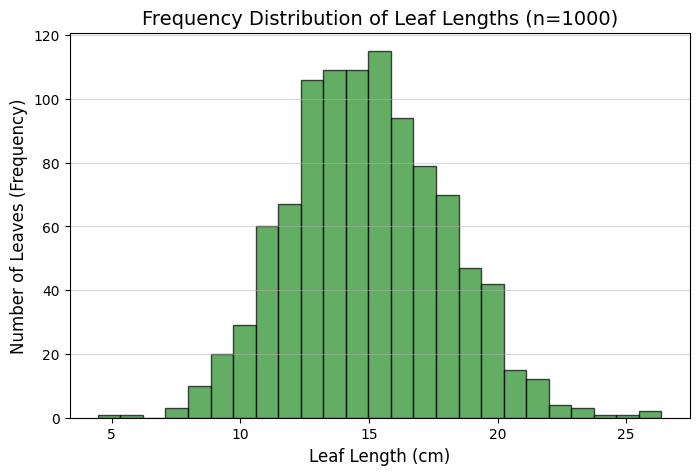

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dataset: Generating 1000 random leaf lengths (Normal Distribution)
# Mean length = 15cm, Standard Deviation = 3cm
leaf_lengths = np.random.normal(15, 3, 1000)
# We are creating a "fake" dataset. In a real lab, this would be your Excel or CSV data. 15 is the average length, 3 is the standard deviation (how much they vary), and 1000 is the number of leaves we measured. This creates a Normal Distribution (Bell Curve), which is very common in nature.
# 2. Create Histogram
plt.figure(figsize=(8, 5))

# 'bins' defines how many bars to split the data into; in Histogram bar is called as bins
# 'alpha' makes it slightly transparent
# 'edgecolor' makes individual bars visible
plt.hist(leaf_lengths, bins=25, color='forestgreen', edgecolor='black', alpha=0.7)
"""
This is the main command. Let's look at its "arguments":

bins=20: This is the most important part for students to understand. It tells Python: "Take the range of my data (e.g., from 5cm to 25cm) and chop it into 20 equal buckets." It then counts how many leaves fall into each bucket.

color='forestgreen': Sets the fill color of the bars.

edgecolor='black': Draws a line around each bar. Without this, the bars often blend together into one big green blob.

alpha=0.7: This makes the bars 70% solid (30% transparent). It makes the graph look professional and easier to see if you add grid lines behind it.
"""
# 3. Annotations
plt.title('Frequency Distribution of Leaf Lengths (n=1000)', fontsize=14)
plt.xlabel('Leaf Length (cm)', fontsize=12)
plt.ylabel('Number of Leaves (Frequency)', fontsize=12)
plt.grid(axis='y', alpha=0.5) # Horizontal grid lines only

# 4. Display
plt.show()

___

**5.Box Plot (The "Whisker" Plot)**

Crucial for biology research to show spread, medians, and outliers.

Biological Case: Comparing the range of Vitamin C levels in different citrus fruits. It shows the "Inner Quartile Range" clearly.

Key Function: plt.boxplot(data)

**The Box Plot: Gene Expression Comparison**

Box plots (or Whisker plots) are the gold standard in biology papers. They show the median, spread (quartiles), and outliers of different groups.

/tmp/ipykernel_870/3571833172.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=False)


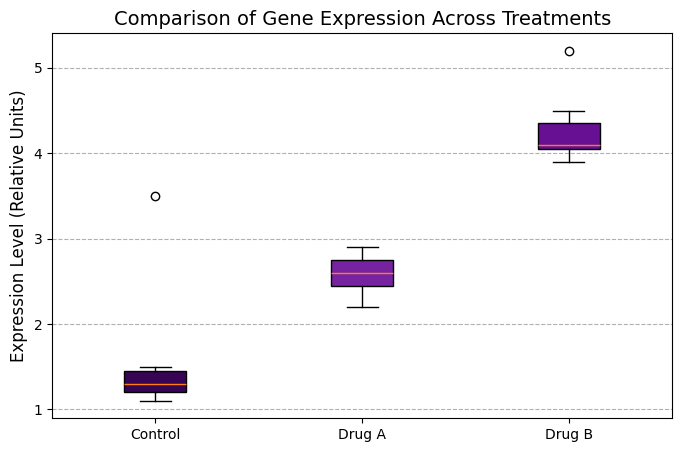

In [ ]:
import matplotlib.pyplot as plt

# 1. Dataset: Gene expression levels (arbitrary units) for 3 conditions
control = [1.2, 1.5, 1.4, 1.1, 3.5, 1.3, 1.2] # Note the 3.5 outlier
treated_a = [2.5, 2.8, 2.2, 2.9, 2.6, 2.4, 2.7]
treated_b = [4.1, 4.5, 3.9, 5.2, 4.0, 4.2, 4.1]

data_to_plot = [control, treated_a, treated_b]
labels = ['Control', 'Drug A', 'Drug B']

# 2. Create Box Plot
plt.figure(figsize=(8, 5))

# 'patch_artist=True' allows us to fill the boxes with color
box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=False)

# 3. Customizing Colors
colors = ['#380554', '#7723A1', '#681094']

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

"""
Think of a zipper on a jacket. It takes one "tooth" from the left side and matches it with one "tooth" from the right side.
zip(box['boxes'], colors) creates pairs like this:

Pair 1: (Box Object 1, 'skyblue')

Pair 2: (Box Object 2, 'lightgreen')

Pair 3: (Box Object 3, 'salmon')
"""
# 4. Annotations
plt.title('Comparison of Gene Expression Across Treatments', fontsize=14)
plt.ylabel('Expression Level (Relative Units)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=1.0)

plt.show()

___
**6.Pie Chart (Proportions)**

Used for showing parts of a whole.

Biological Case: The chemical composition of a cell (Water, Protein, Lipids, etc.) or the percentage of different bases (A, T, G, C) in a DNA sequence.

Key Function: plt.pie(sizes, labels=labels)

**The Pie Chart: Cellular Composition**

Pie charts are best for showing how a "whole" organism or cell is divided into its constituent parts.



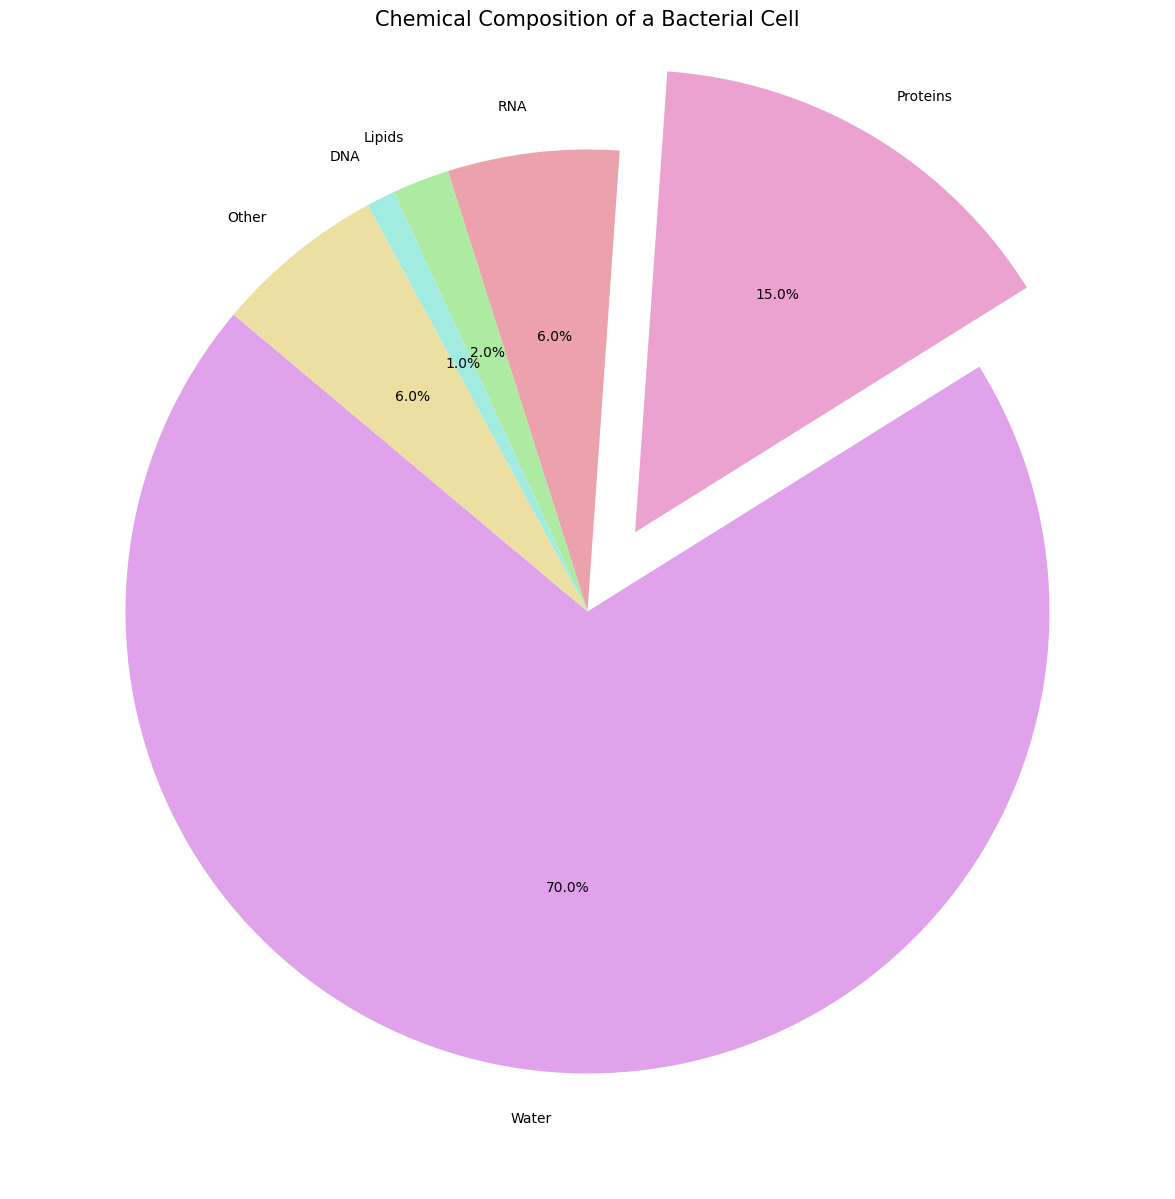

In [ ]:
import matplotlib.pyplot as plt

# 1. Dataset: Composition of a typical bacterial cell (by weight)
components = ['Water', 'Proteins', 'RNA', 'Lipids', 'DNA', 'Other']
percentages = [70, 15, 6, 2, 1, 6]

# 2. Create Pie Chart
plt.figure(figsize=(15, 15))

# 'explode' pulls a slice out (let's highlight Proteins)
explode = (0, 0.2, 0, 0, 0, 0)
color_code = ['#E0A2EB', '#EBA2D1', '#EBA2AD', '#ADEBA2', '#A2EBE0', '#EBE0A2']
# 'autopct' formats the numbers to show percentages automatically
plt.pie(percentages, labels=components, explode=explode, autopct='%1.1f%%', colors=color_code, startangle=140)
# in plt.pie, in bracket Sizes first then labels, then explode, then autopct (percentage), colors,
# 3. Annotations
plt.title('Chemical Composition of a Bacterial Cell', fontsize=15)

# 4. Display
plt.show()

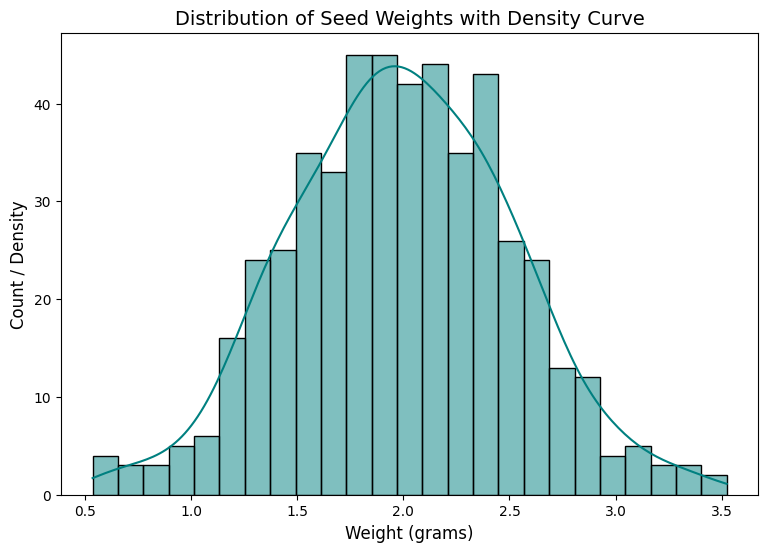

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # New library for statistical plotting

# 1. Generate random biological data
# Let's imagine measuring 500 seeds' weights (Mean=2g, StdDev=0.5)
seed_weights = np.random.normal(2.0, 0.5, 500)

# 2. Create the Plot
plt.figure(figsize=(9, 6))

# sns.histplot is a powerful version of plt.hist
# 'kde=True' is the magic command that adds the density curve
sns.histplot(seed_weights, bins=25, kde=True, color="teal", edgecolor="black")

# 3. Annotations
plt.title('Distribution of Seed Weights with Density Curve', fontsize=14)
plt.xlabel('Weight (grams)', fontsize=12)
plt.ylabel('Count / Density', fontsize=12)

# 4. Show it
plt.show()

**Welcome to the Day 28**

# **Mini Project: how to open and use external file in Colab**

Dataset used: bacteria set 200 (Source: Kaggle)

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Dataset
file_path = '/content/drive/MyDrive/Python for Biologists/data files/bacteria_list_200.csv'
df = pd.read_csv(file_path)
df.head()
# df.head will show first 5 rows of csv file/table/data frame

,Name,Family,Where Found,Harmful to Humans
0,Escherichia coli,Enterobacteriaceae,Intestinal tract,Yes
1,Staphylococcus aureus,Staphylococcaceae,"Skin, nasal passages",Yes
2,Lactobacillus acidophilus,Lactobacillaceae,Human mouth & intestine,No
3,Bacillus subtilis,Bacillaceae,Soil,No
4,Clostridium botulinum,Clostridiaceae,"Soil, improperly canned foods",Yes


In [ ]:
# Showing the Bot Row Data
df.tail()
# By default df.tail() will show last 5 rows

,Name,Family,Where Found,Harmful to Humans
194,Rathayibacter toxicus,Microbacteriaceae,Infected grasses,Yes
195,Simonsiella muelleri,Simonsiellaceae,Animal mucous membranes,No
196,Tepidimonas arfidensis,Comamonadaceae,Thermal springs,No
197,Ulvibacter litoralis,Flavobacteriaceae,Marine environments,No
198,Vibrio vulnificus,Vibrionaceae,Marine environments,Yes


In [ ]:
# Showing All Colums in Dataset
print(df.columns)

Index(['Name', 'Family', 'Where Found', 'Harmful to Humans'], dtype='object')


In [ ]:
# Showing the Info of Dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               199 non-null    object
 1   Family             199 non-null    object
 2   Where Found        199 non-null    object
 3   Harmful to Humans  199 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB
None


In [ ]:
# Description of Dataset
print(df.describe())

                     Name              Family Where Found Harmful to Humans
count                 199                 199         199               199
unique                194                  93         120                 3
top     Coxiella burnetii  Enterobacteriaceae        Soil                No
freq                    2                  21          17               102


In [ ]:
# Showing the Shape of Data
print(df.shape)

(199, 4)


In [ ]:
# Showing the Type of Data
print(df.dtypes)

Name                 object
Family               object
Where Found          object
Harmful to Humans    object
dtype: object


In [ ]:
# Checking the Null Value in Each Columns
missing_values = df.isnull().sum()
missing_values

,0
Name,0
Family,0
Where Found,0
Harmful to Humans,0


In [ ]:
# Checking the Duplicate Data
# This shows both the original and the copies
all_duplicates = df[df.duplicated(keep=False)]
print(all_duplicates.sort_values(by=list(df.columns)))

                      Name              Family              Where Found  \
45       Coxiella burnetii        Coxiellaceae         Infected animals   
55       Coxiella burnetii        Coxiellaceae         Infected animals   
38  Francisella tularensis     Francisellaceae  Infected animals, water   
58  Francisella tularensis     Francisellaceae  Infected animals, water   
37   Gardnerella vaginalis  Bifidobacteriaceae      Genitourinary tract   
59   Gardnerella vaginalis  Bifidobacteriaceae      Genitourinary tract   

   Harmful to Humans  
45               Yes  
55               Yes  
38               Yes  
58               Yes  
37               Yes  
59               Yes  


In [ ]:
# Cleaning the Duplicate
df = df.drop_duplicates()

# Re-Checking After Cleaning
df.shape

(196, 4)

In [ ]:
# Distribution Data Based on Unique Data
df.nunique()

,0
Name,194
Family,93
Where Found,120
Harmful to Humans,3


In [ ]:
# Unique Data on Column "Harmful to Humans"
df["Harmful to Humans"].unique()

array(['Yes', 'No', ' Yes'], dtype=object)

In [ ]:
# Unique Data on Column "Families"
df["Family"].unique()

array(['Enterobacteriaceae', 'Staphylococcaceae', 'Lactobacillaceae',
       'Bacillaceae', 'Clostridiaceae', 'Streptococcaceae',
       'Pseudomonadaceae', 'Mycobacteriaceae', 'Vibrionaceae',
       'Helicobacteraceae', 'Neisseriaceae', 'Bacteroidaceae',
       'Campylobacteraceae', 'Listeriaceae', 'Acetobacteraceae',
       'Propionibacteriaceae', 'Bifidobacteriaceae', 'Legionellaceae',
       'Spirochaetaceae', 'Chlamydiaceae', 'Mycoplasmataceae',
       'Pasteurellaceae', 'Leptospiraceae', 'Enterococcaceae',
       'Corynebacteriaceae', 'Rickettsiaceae', 'Francisellaceae',
       'Actinomycetaceae', 'Fusobacteriaceae', 'Brucellaceae',
       'Coxiellaceae', 'Streptomycetaceae', 'Rhodobacteraceae',
       'Caulobacteraceae', 'Nostocaceae', 'Nitrosomonadaceae',
       'Rhizobiaceae', 'Alcaligenaceae', 'Dermatophilaceae',
       'Anaplasmataceae', 'Ignatzschineriaceae', 'Oxalobacteraceae',
       'Moraxellaceae', 'Deinococcaceae', 'Comamonadaceae',
       'Xanthomonadaceae', 'Sphingom

In [ ]:
# Cleaning Data by Deleting the Unnecessary String
df["Harmful to Humans"] = df["Harmful to Humans"].str.strip()

# Verification
df["Harmful to Humans"].unique()

array(['Yes', 'No'], dtype=object)

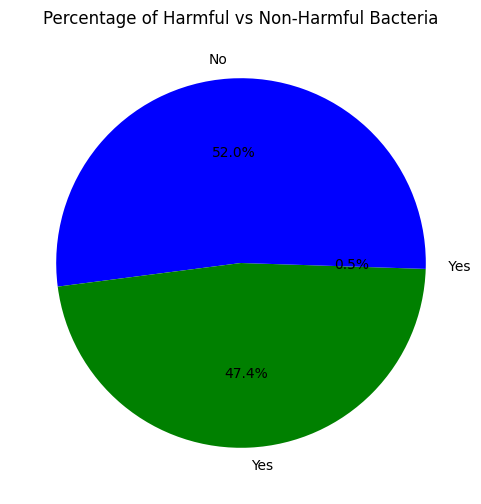

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the Types of Bacteria
harmful_counts = df["Harmful to Humans"].value_counts()

# Creating the Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(harmful_counts, labels=harmful_counts.index, autopct='%1.1f%%', colors=['blue', 'green'])
plt.title("Percentage of Harmful vs Non-Harmful Bacteria")
plt.show()

/tmp/ipykernel_363/455208681.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_families.values, y=top_families.index, palette="viridis")


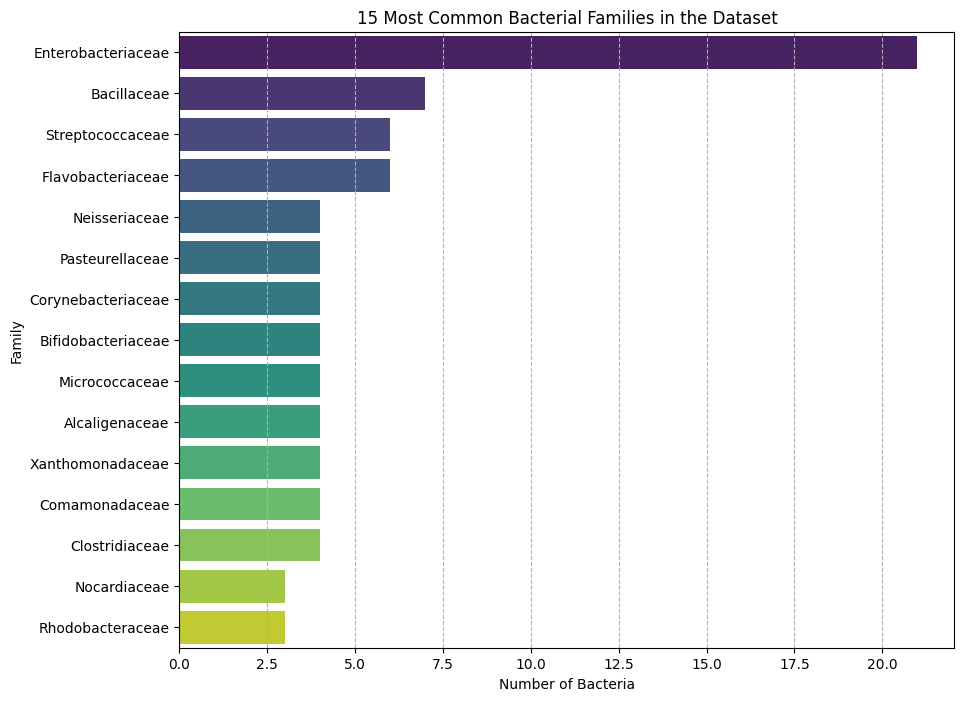

In [ ]:
# Calculating the Families of Bacteria
top_families = df["Family"].value_counts().nlargest(15)

# Visualization with Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(x=top_families.values, y=top_families.index, palette="viridis")
plt.xlabel("Number of Bacteria")
plt.ylabel("Family")
plt.title("15 Most Common Bacterial Families in the Dataset")
plt.grid(axis='x', linestyle='--', alpha=1.0)
plt.show()

/tmp/ipykernel_671/548158475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette="magma")


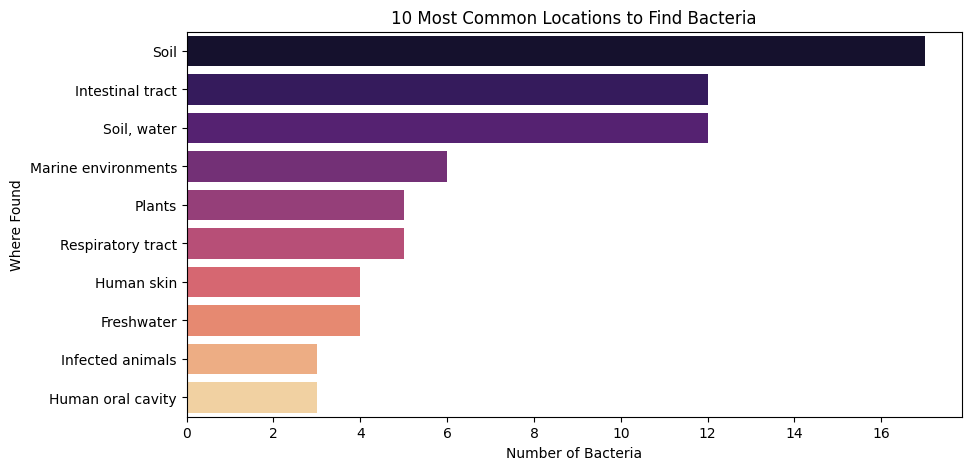

In [ ]:
# Calculate the most common locations where bacteria are found
top_locations = df["Where Found"].value_counts().nlargest(10)

# Visualization with Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="magma")
plt.xlabel("Number of Bacteria")
plt.ylabel("Where Found")
plt.title("10 Most Common Locations to Find Bacteria")
plt.show()